# Scikit-Learn Neural Nets Exercise

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [119]:
# Read in transfusion.data
# Predict if someone donated blood in March 2007
# (1 stand for donating blood; 0 stands for not donating blood).
df = pd.read_csv('transfusion.data')

In [120]:
df.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [121]:
df.shape

(748, 5)

In [122]:
df.isna().sum().sum()

np.int64(0)

<Axes: xlabel='whether he/she donated blood in March 2007', ylabel='count'>

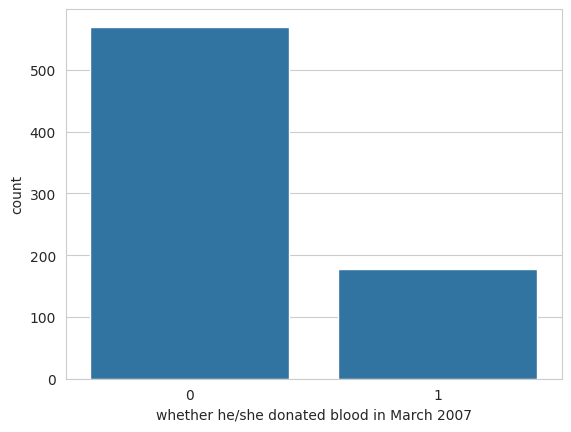

In [123]:
sns.countplot(data=df, x='whether he/she donated blood in March 2007')

In [124]:
# Create X and y
X = df.drop('whether he/she donated blood in March 2007', axis=1)
y = df['whether he/she donated blood in March 2007']

In [125]:
X.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months)
0,2,50,12500,98
1,0,13,3250,28
2,1,16,4000,35
3,2,20,5000,45
4,1,24,6000,77


In [126]:
y.head()

0    1
1    1
2    1
3    1
4    0
Name: whether he/she donated blood in March 2007, dtype: int64

In [127]:
# Split the data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

In [128]:
model = Pipeline([('scaler', StandardScaler()),
                 ('model', MLPClassifier(early_stopping=True, max_iter=1000))])

In [129]:
param_grid = {'model__hidden_layer_sizes':((20,),(10, 10), (5,5,5)),
              'model__activation':('relu', 'tanh'),
              'model__learning_rate_init': [0.001, 0.01]
             }

In [130]:
grid = GridSearchCV(model, param_grid)

In [131]:
# Fit the classifier to the training set
grid.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__activation': ('relu', ...), 'model__hidden_layer_sizes': ((20,), ...), 'model__learning_rate_init': [0.001, 0.01]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [132]:
grid.best_params_

{'model__activation': 'tanh',
 'model__hidden_layer_sizes': (10, 10),
 'model__learning_rate_init': 0.01}

In [133]:
grid.cv_results_['mean_test_score']

array([0.72653465, 0.77035644, 0.56247525, 0.77045545, 0.64647525,
       0.66247525, 0.47067327, 0.78249505, 0.73647525, 0.79243564,
       0.65447525, 0.73469307])

In [134]:
grid.cv_results_['std_test_score']

array([0.03936268, 0.03280475, 0.24340317, 0.00638981, 0.20418927,
       0.21135291, 0.15328945, 0.01858217, 0.04059206, 0.01913906,
       0.21233383, 0.04277249])

In [135]:
# Make predictions
predictions = grid.predict(X_test)

In [136]:
# 1. Extract the best MLP model from your pipeline
best_mlp = grid.best_estimator_.named_steps['model']

In [137]:
# 2. Convert the loss_curve_ list into a DataFrame for Seaborn
loss_data = pd.DataFrame({
    'Iteration': range(len(best_mlp.loss_curve_)),
    'Loss': best_mlp.loss_curve_})

Text(0, 0.5, 'Loss (Error rate)')

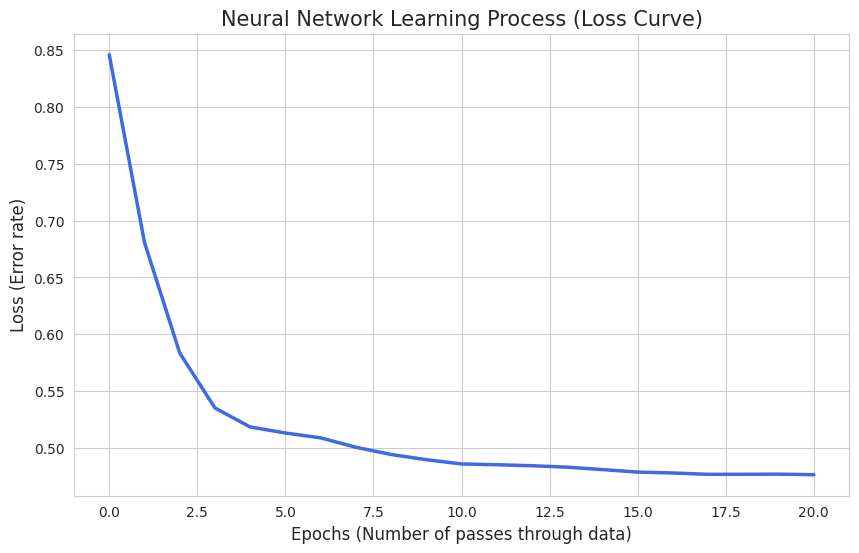

In [138]:
# 3. Create the plot using Seaborn
plt.figure(figsize=(10, 6))
g = sns.lineplot(data=loss_data, x='Iteration', y='Loss', linewidth=2.5, color='royalblue')
g.set_title('Neural Network Learning Process (Loss Curve)', fontsize=15)
g.set_xlabel('Epochs (Number of passes through data)', fontsize=12)
g.set_ylabel('Loss (Error rate)', fontsize=12)

In [139]:
print(f"Training stopped after {best_mlp.n_iter_} iterations.")

Training stopped after 21 iterations.


In [140]:
# Print the accuracy
accuracy_score(y_test, predictions)

0.7813765182186235

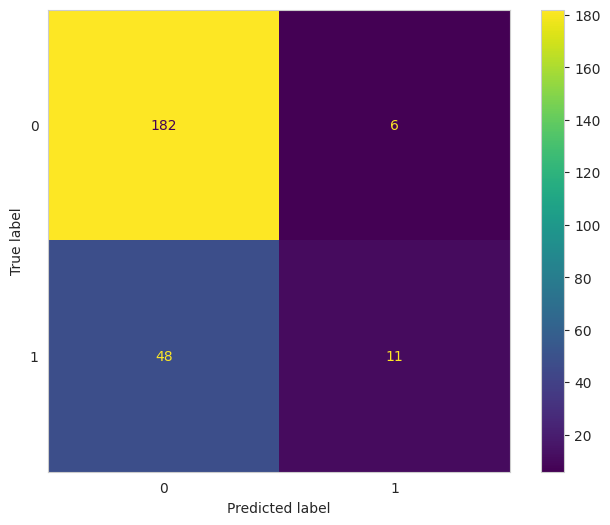

In [141]:
# Print the confusion matrix
cm = confusion_matrix(y_test, predictions, labels=grid.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=grid.classes_)
disp.plot(ax=ax)
ax.grid(False)
plt.show()

In [142]:
# Display the classification report 
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.79      0.97      0.87       188
           1       0.65      0.19      0.29        59

    accuracy                           0.78       247
   macro avg       0.72      0.58      0.58       247
weighted avg       0.76      0.78      0.73       247



Happy Learning!